In [1]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# Visualization style setup
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.sans-serif": "DejaVu Sans", "font.size": 10})

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1. Load Dataset
df = pd.read_csv("Mobile Reviews Sentiment null.csv")

# 2. Check and Remove Duplicate Records
initial_rows = len(df)
df = df.drop_duplicates()
print(f"Removed {initial_rows - len(df)} exact duplicates.")

# 3. Handle Data Type Conversions & Feature Imputation
# 3a. Convert review_date to datetime
df["review_date"] = pd.to_datetime(df["review_date"], errors="coerce")


Removed 0 exact duplicates.


In [3]:
display(df)

,review_id,customer_name,age,brand,model,price_usd,price_local,currency,exchange_rate_to_usd,rating,...,language,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,source
0,1,Aryan Maharaj,45,Realme,Realme 12 Pro,337.31,₹27996.73,INR,83.00,2.0,...,Hindi,2023-11-06,True,1,1,3,2,1,1,Amazon
1,2,Davi Miguel Sousa,18,Realme,Realme 12 Pro,307.78,R$1754.35,BRL,5.70,4.0,...,Portuguese,2023-03-30,True,3,2,4,3,2,5,Flipkart
2,3,Pahal Balay,27,Google,Pixel 6,864.53,₹71755.99,INR,83.00,4.0,...,Hindi,2022-12-07,True,3,5,3,2,4,8,AliExpress
3,4,David Guzman,19,Xiaomi,Redmi Note 13,660.94,د.إ2425.65,AED,3.67,3.0,...,English,2025-03-11,False,1,3,2,1,2,3,Amazon
4,5,Yago Leão,38,Motorola,Edge 50,792.13,R$4515.14,BRL,5.70,3.0,...,Portuguese,2023-09-29,True,3,3,2,2,1,0,BestBuy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,Rebecca Pratt,18,Realme,Realme 12 Pro,526.10,A$804.93,AUD,1.53,4.0,...,English,2023-08-17,False,3,3,4,3,5,4,BestBuy
49996,49997,Dr. Tiffany Patterson,28,Samsung,Galaxy Note 20,911.85,A$1395.13,AUD,1.53,3.0,...,English,2023-09-23,False,3,2,4,1,3,2,AliExpress
49997,49998,Alexandra Singh,21,Apple,iPhone SE,1155.32,د.إ4240.02,AED,3.67,NaN,...,English,2023-04-04,True,2,3,4,4,5,4,Amazon
49998,49999,Robert Morris,31,Realme,Realme Narzo 70,459.04,NaN,USD,1.00,3.0,...,English,2025-07-11,True,1,2,2,1,3,6,NaN


In [4]:
# 3b. Impute missing price_usd using price_local & exchange_rate_to_usd
def clean_local_price(val):
    if pd.isnull(val):
        return np.nan
    # Remove currency symbols and formatting characters
    cleaned = "".join(c for c in str(val) if c.isdigit() or c == ".")
    try:
        return float(cleaned)
    except ValueError:
        return np.nan

# Extract numeric local price
df["price_local_numeric"] = df["price_local"].apply(clean_local_price)

# Calculate missing price_usd where local price and exchange rate exist
missing_usd_mask = df["price_usd"].isnull() & df["price_local_numeric"].notnull()
df.loc[missing_usd_mask, "price_usd"] = (
    df.loc[missing_usd_mask, "price_local_numeric"]
    / df.loc[missing_usd_mask, "exchange_rate_to_usd"]
)

# For any remaining missing price_usd, impute by median of that specific model
df["price_usd"] = df.groupby("model")["price_usd"].transform(
    lambda x: x.fillna(x.median())
)

In [5]:
# 3c. Impute missing overall ratings using feature-specific ratings mean
aspect_cols = [
    "battery_life_rating",
    "camera_rating",
    "performance_rating",
    "design_rating",
    "display_rating",
]
df["rating"] = df["rating"].fillna(df[aspect_cols].mean(axis=1).round(1))


In [6]:
# 3d. Impute missing sentiment based on rating threshold
sentiment_fill = df["rating"].apply(
    lambda r: "Positive" if r >= 4.0 else ("Neutral" if r == 3.0 else "Negative")
)
df["sentiment"] = df["sentiment"].fillna(sentiment_fill)

# 3e. Impute missing source with the mode
df["source"] = df["source"].fillna(df["source"].mode()[0])


In [7]:
# 4. Feature Selection & Engineering
# Construct engagement & aspect composite metrics
df["engagement_score"] = np.log1p(df["helpful_votes"])
df["overall_spec_score"] = df[aspect_cols].mean(axis=1)

# Features selected for product segmentation & recommendation modeling
num_features = [
    "price_usd",
    "rating",
    "engagement_score",
    "overall_spec_score",
    "battery_life_rating",
    "camera_rating",
    "performance_rating",
    "design_rating",
    "display_rating",
]
cat_features = ["brand", "country", "model"]

In [8]:
# 5. Categorical Encoding (One-Hot Encoding)
encoder = OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore")
encoded_cats = encoder.fit_transform(df[cat_features])
encoded_cat_cols = encoder.get_feature_names_out(cat_features)
df_encoded_cats = pd.DataFrame(
    encoded_cats, columns=encoded_cat_cols, index=df.index
)

In [9]:
# 6. Standardization & Feature Scaling
scaler = StandardScaler()
scaled_nums = scaler.fit_transform(df[num_features])
df_scaled_nums = pd.DataFrame(
    scaled_nums,
    columns=[f"{col}_scaled" for col in num_features],
    index=df.index,
)


In [10]:
# 7. Combine into Final Preprocessed Modeling Matrix
processed_df = pd.concat([df_scaled_nums, df_encoded_cats], axis=1)

print("Preprocessing complete.")
print(f"Final feature matrix shape: {processed_df.shape}")
print(f"Remaining null values across dataset: {processed_df.isnull().sum().sum()}")

Preprocessing complete.
Final feature matrix shape: (50000, 43)
Remaining null values across dataset: 0


In [11]:
processed_df.to_csv('processed_data.csv', index=False)

In [12]:
display(processed_df)

,price_usd_scaled,rating_scaled,engagement_score_scaled,overall_spec_score_scaled,battery_life_rating_scaled,camera_rating_scaled,performance_rating_scaled,design_rating_scaled,display_rating_scaled,brand_Google,...,model_Pixel 8,model_Poco X6,model_Razr 40,model_Realme 12 Pro,model_Realme Narzo 70,model_Redmi Note 13,model_iPhone 13,model_iPhone 14,model_iPhone 15 Pro,model_iPhone SE
0,-1.137414,-0.885373,-1.161903,-1.016864,-1.274238,-1.277067,0.207813,-0.531484,-1.273035,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-1.232734,0.720216,0.695670,0.074485,0.209159,-0.533566,0.948996,0.212933,-0.533449,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.564410,0.720216,1.381246,0.620159,0.209159,1.696937,0.207813,-0.531484,0.945723,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.092762,-0.082579,0.010095,-0.834972,-1.274238,0.209935,-0.533370,-1.275902,-0.533449,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.330709,-0.082579,-2.333902,-0.471190,0.209159,0.209935,-0.533370,-0.531484,-1.273035,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,-0.528015,0.720216,0.387394,0.802050,0.209159,0.209935,0.948996,0.212933,1.685310,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
49996,0.717156,-0.082579,-0.476328,-0.107407,0.209159,-0.533566,0.948996,-1.275902,0.206137,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49997,1.503057,0.399098,0.387394,0.802050,-0.532540,0.209935,0.948996,0.957351,1.685310,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
49998,-0.744479,-0.082579,0.956314,-0.834972,-1.274238,-0.533566,-0.533370,-1.275902,0.206137,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


# EDA

In [13]:
# Statistical summary for key numeric metrics
num_cols = ["price_usd", "rating"] + aspect_cols + ["helpful_votes"]
stats_summary = (
    df[num_cols]
    .describe()
    .T[["count", "mean", "std", "min", "50%", "max"]]
    .rename(columns={"50%": "median"})
)

print("--- Numerical Metrics Summary ---")
stats_summary.round(2)

--- Numerical Metrics Summary ---


,count,mean,std,min,median,max
price_usd,50000.0,689.68,309.80,180.02,637.52,1499.89
rating,50000.0,3.10,1.25,1.00,3.00,5.00
battery_life_rating,50000.0,2.72,1.35,1.00,3.00,5.00
camera_rating,50000.0,2.72,1.35,1.00,3.00,5.00
performance_rating,50000.0,2.72,1.35,1.00,3.00,5.00
design_rating,50000.0,2.71,1.34,1.00,3.00,5.00
display_rating,50000.0,2.72,1.35,1.00,3.00,5.00
helpful_votes,50000.0,3.64,2.43,0.00,3.00,17.00


In [14]:
# Distribution counts
print("--- Brand Distribution ---")
print(df["brand"].value_counts())

print("\n--- Country Distribution ---")
print(df["country"].value_counts())

# Cross-tabulation: Brand vs Country
print("\n--- Brand by Country Cross-Tabulation ---")
brand_country_ct = pd.crosstab(df["brand"], df["country"])
brand_country_ct

--- Brand Distribution ---
brand
Xiaomi      7241
Google      7234
Apple       7144
OnePlus     7136
Realme      7132
Motorola    7061
Samsung     7052
Name: count, dtype: int64

--- Country Distribution ---
country
USA          6435
Brazil       6419
UAE          6261
Australia    6219
UK           6210
Canada       6170
Germany      6162
India        6124
Name: count, dtype: int64

--- Brand by Country Cross-Tabulation ---


country,Australia,Brazil,Canada,Germany,India,UAE,UK,USA
brand,,,,,,,,
Apple,910,925,889,890,875,903,877,875
Google,897,909,930,861,918,894,872,953
Motorola,874,899,880,837,857,899,888,927
OnePlus,871,910,875,929,846,924,908,873
Realme,914,903,839,846,876,916,877,961
Samsung,852,916,868,888,891,864,877,896
Xiaomi,901,957,889,911,861,861,911,950


In [15]:
# Aggregate performance metrics at model level
model_summary = (
    df.groupby(["brand", "model"])
    .agg(
        review_count=("rating", "count"),
        mean_rating=("rating", "mean"),
        median_price=("price_usd", "median"),
        mean_battery=("battery_life_rating", "mean"),
        mean_camera=("camera_rating", "mean"),
        mean_perf=("performance_rating", "mean"),
        mean_design=("design_rating", "mean"),
        mean_display=("display_rating", "mean"),
    )
    .reset_index()
)

# Sort models by mean rating
model_summary_sorted = model_summary.sort_values(
    by="mean_rating", ascending=False
)

print("--- Top 5 Rated Models ---")
display(
    model_summary_sorted.head(5)[
        ["brand", "model", "mean_rating", "median_price", "review_count"]
    ].round(2)
)

print("\n--- Lowest 5 Rated Models ---")
display(
    model_summary_sorted.tail(5)[
        ["brand", "model", "mean_rating", "median_price", "review_count"]
    ].round(2)
)

--- Top 5 Rated Models ---


,brand,model,mean_rating,median_price,review_count
1,Apple,iPhone 14,3.15,1091.26,1788
16,Samsung,Galaxy Note 20,3.13,905.24,1789
0,Apple,iPhone 13,3.13,1108.24,1767
13,Realme,Realme 12 Pro,3.13,396.42,3535
12,OnePlus,OnePlus Nord 3,3.12,670.36,2380



--- Lowest 5 Rated Models ---


,brand,model,mean_rating,median_price,review_count
19,Xiaomi,Mi 13 Pro,3.08,443.21,2445
15,Samsung,Galaxy A55,3.07,900.75,1788
7,Motorola,Edge 50,3.07,512.09,2315
2,Apple,iPhone 15 Pro,3.06,1106.48,1793
17,Samsung,Galaxy S24,3.05,892.54,1761


In [16]:
# Correlation matrix computation
corr_cols = ["price_usd", "rating"] + aspect_cols + ["helpful_votes"]
corr_matrix = df[corr_cols].corr()

print("--- Correlation Matrix ---")
corr_matrix.round(3)

--- Correlation Matrix ---


,price_usd,rating,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes
price_usd,1.000,0.001,0.001,0.002,-0.005,0.003,-0.000,0.003
rating,0.001,1.000,0.763,0.761,0.756,0.756,0.758,0.458
battery_life_rating,0.001,0.763,1.000,0.589,0.584,0.586,0.584,0.356
camera_rating,0.002,0.761,0.589,1.000,0.580,0.581,0.582,0.355
performance_rating,-0.005,0.756,0.584,0.580,1.000,0.576,0.581,0.353
design_rating,0.003,0.756,0.586,0.581,0.576,1.000,0.579,0.353
display_rating,-0.000,0.758,0.584,0.582,0.581,0.579,1.000,0.352
helpful_votes,0.003,0.458,0.356,0.355,0.353,0.353,0.352,1.000


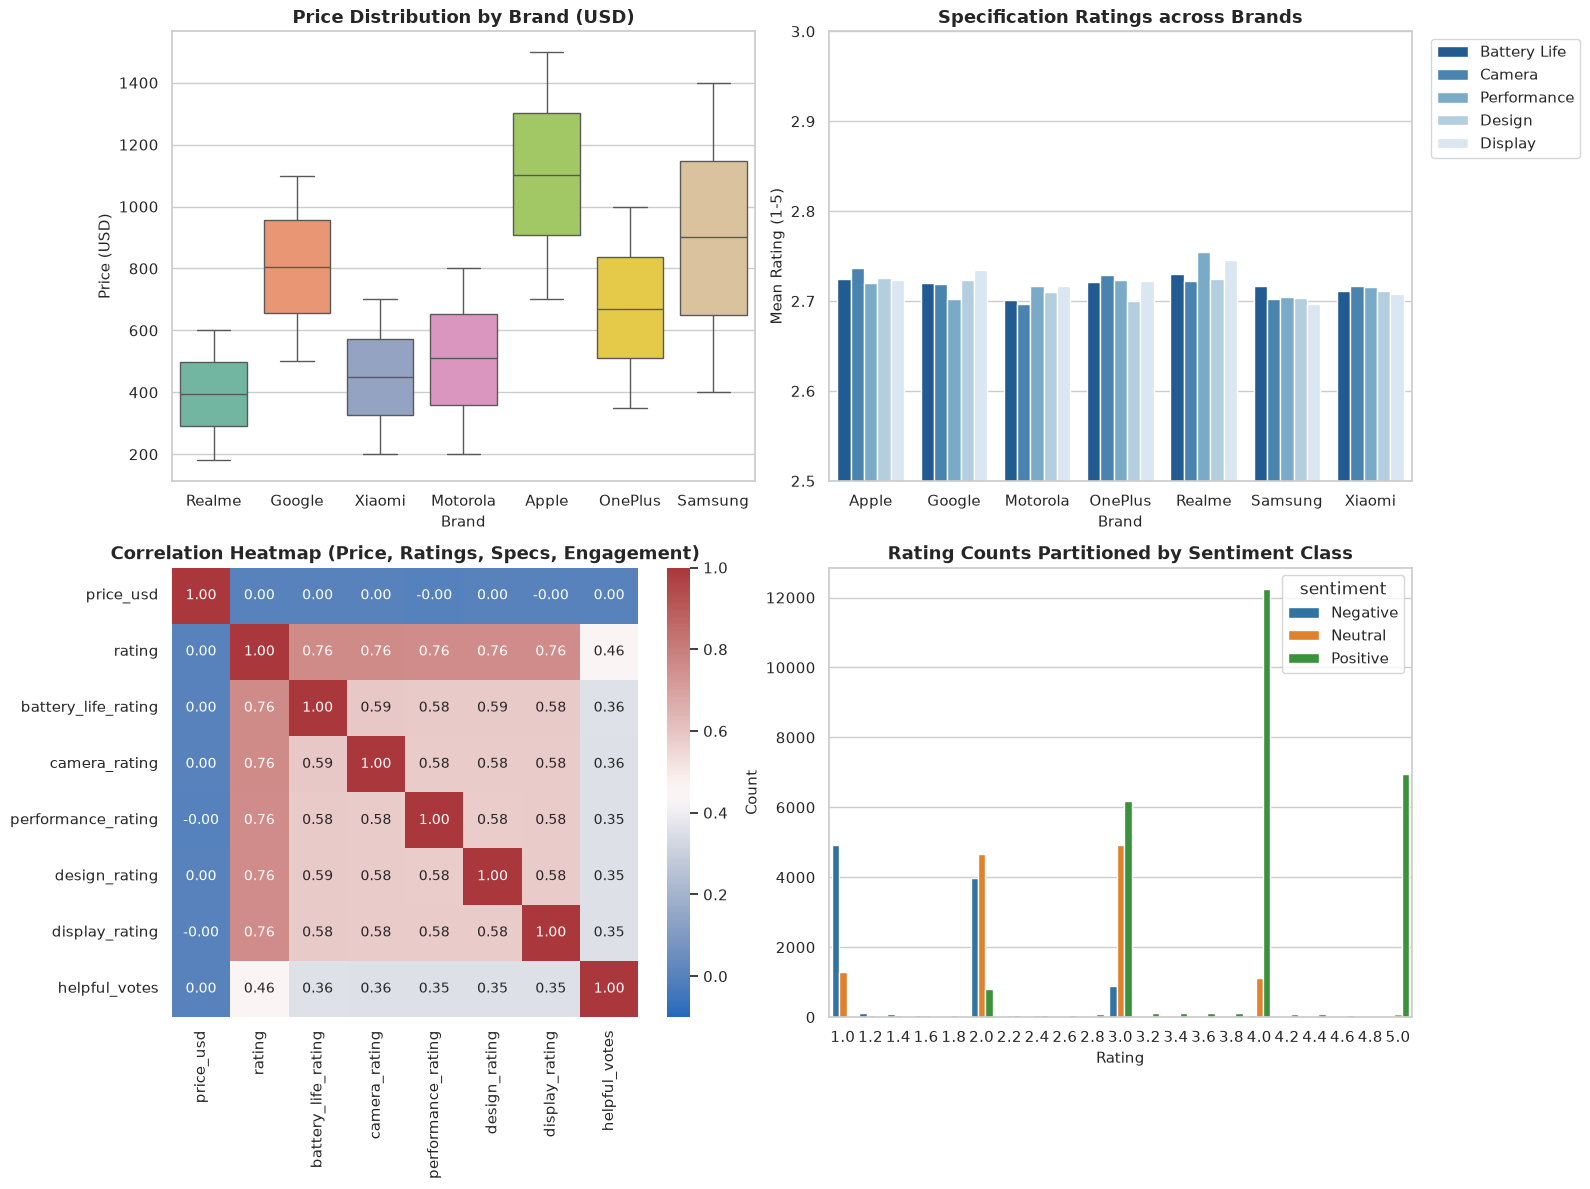

In [17]:
# Create a 2x2 EDA dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Price Distribution by Brand (USD)
sns.boxplot(ax=axes[0, 0], data=df, x="brand", y="price_usd", palette="Set2")
axes[0, 0].set_title(
    "Price Distribution by Brand (USD)", fontsize=13, fontweight="bold"
)
axes[0, 0].set_xlabel("Brand", fontsize=11)
axes[0, 0].set_ylabel("Price (USD)", fontsize=11)

# 2. Average Specification Ratings by Brand
brand_spec = df.groupby("brand")[aspect_cols].mean().reset_index()
brand_spec_melted = brand_spec.melt(
    id_vars="brand", var_name="Specification", value_name="Average Rating"
)
brand_spec_melted["Specification"] = (
    brand_spec_melted["Specification"]
    .str.replace("_rating", "")
    .str.replace("_", " ")
    .str.title()
)

sns.barplot(
    ax=axes[0, 1],
    data=brand_spec_melted,
    x="brand",
    y="Average Rating",
    hue="Specification",
    palette="Blues_r",
)
axes[0, 1].set_title(
    "Specification Ratings across Brands", fontsize=13, fontweight="bold"
)
axes[0, 1].set_xlabel("Brand", fontsize=11)
axes[0, 1].set_ylabel("Mean Rating (1-5)", fontsize=11)
axes[0, 1].set_ylim(2.5, 3.0)
axes[0, 1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")

# 3. Correlation Heatmap
sns.heatmap(
    corr_matrix,
    ax=axes[1, 0],
    annot=True,
    fmt=".2f",
    cmap="vlag",
    vmin=-0.1,
    vmax=1.0,
    cbar=True,
)
axes[1, 0].set_title(
    "Correlation Heatmap (Price, Ratings, Specs, Engagement)",
    fontsize=13,
    fontweight="bold",
)

# 4. Rating Distribution by Sentiment Class
sns.countplot(
    ax=axes[1, 1], data=df, x="rating", hue="sentiment", palette="tab10"
)
axes[1, 1].set_title(
    "Rating Counts Partitioned by Sentiment Class",
    fontsize=13,
    fontweight="bold",
)
axes[1, 1].set_xlabel("Rating", fontsize=11)
axes[1, 1].set_ylabel("Count", fontsize=11)

plt.tight_layout()
plt.show()

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Feature Selection & Scaling for Segmentation

features = [
    "price_usd",
    "rating",
    "battery_life_rating",
    "camera_rating",
    "performance_rating",
    "design_rating",
    "display_rating",
    "helpful_votes",
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

# Determine Optimal K Using the Elbow Method

wcss = []
k_range = range(2, 8)
sample_subset = X_scaled[:10000]  # representative sample for speed

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(sample_subset)
    wcss.append(kmeans.inertia_)

# Fit K-Means Model (k=4)

k_optimal = 4
kmeans_model = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df["cluster"] = kmeans_model.fit_predict(X_scaled)

# Map Segment Labels Based on Characteristic Profiles

segment_mapping = {
    0: "Highly Satisfied Advocates",  # High ratings (~4.5), High specs (~4.1)
    1: "Budget Value Seekers",  # Low/Mid price (~$490), Moderate ratings (~3.2)
    2: "Critical Dissatisfied Users",  # Low ratings (~1.6), Low engagement
    3: "Premium Flagship Buyers",  # High price (~$1,089), Above-average specs
}
df["segment_name"] = df["cluster"].map(segment_mapping)

# Dimensionality Reduction (PCA) for Visualization

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df["pca_1"] = X_pca[:, 0]
df["pca_2"] = X_pca[:, 1]

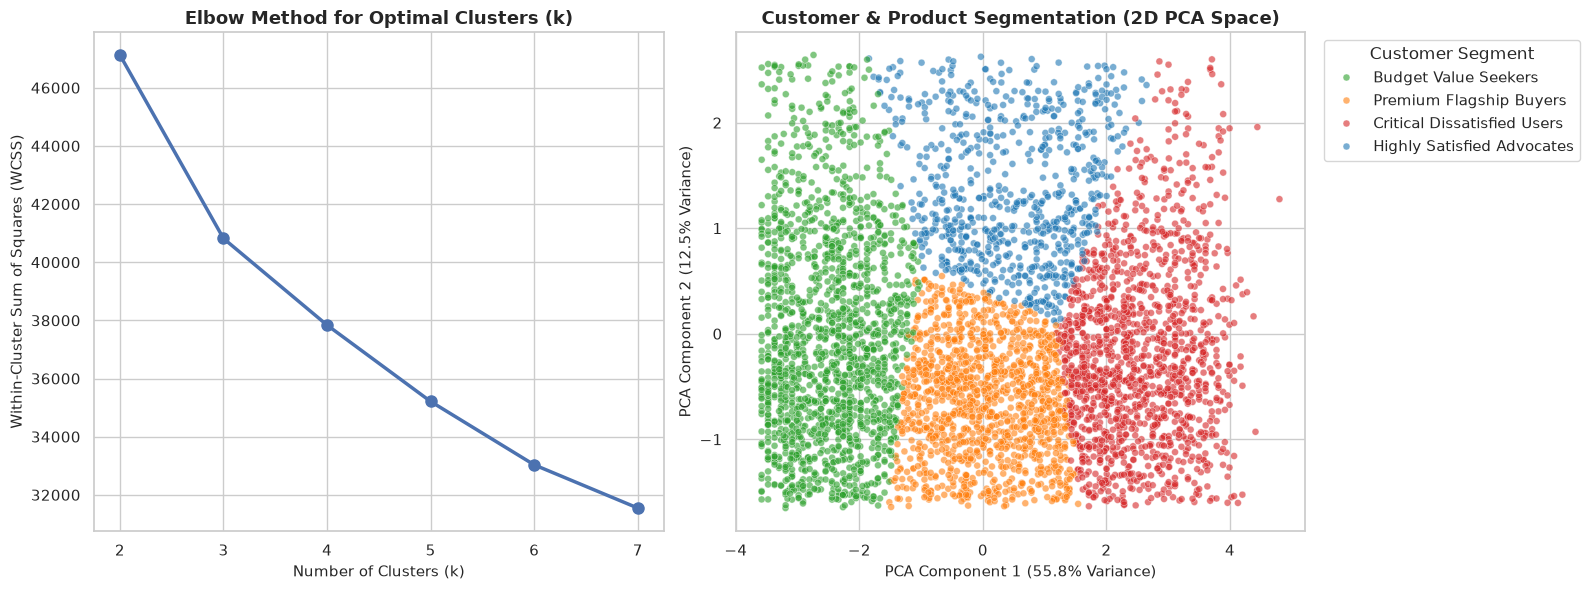

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Elbow Curve
axes[0].plot(k_range, wcss, "bo-", linewidth=2.5, markersize=8)
axes[0].set_title(
    "Elbow Method for Optimal Clusters (k)", fontsize=13, fontweight="bold"
)
axes[0].set_xlabel("Number of Clusters (k)", fontsize=11)
axes[0].set_ylabel("Within-Cluster Sum of Squares (WCSS)", fontsize=11)

# Plot 2: 2D PCA Cluster Scatter
palette = ["#2ca02c", "#ff7f0e", "#d62728", "#1f77b4"]
sns.scatterplot(
    ax=axes[1],
    data=df.iloc[:5000],  # 5,000 points for crisp visual clarity
    x="pca_1",
    y="pca_2",
    hue="segment_name",
    palette=palette,
    alpha=0.6,
    s=25,
)
axes[1].set_title(
    "Customer & Product Segmentation (2D PCA Space)",
    fontsize=13,
    fontweight="bold",
)
axes[1].set_xlabel(
    f"PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)",
    fontsize=11,
)
axes[1].set_ylabel(
    f"PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)",
    fontsize=11,
)
axes[1].legend(title="Customer Segment", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [20]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

# Product-Level Feature Aggregation
# Compile device-level hardware, rating, and economic profiles
product_catalog = (
    df.groupby(["brand", "model"])
    .agg(
        median_price=("price_usd", "median"),
        mean_rating=("rating", "mean"),
        battery=("battery_life_rating", "mean"),
        camera=("camera_rating", "mean"),
        performance=("performance_rating", "mean"),
        design=("design_rating", "mean"),
        display=("display_rating", "mean"),
        review_count=("review_id", "count"),
    )
    .reset_index()
)

# Feature Normalization & Cosine Similarity Matrix

feature_columns = [
    "median_price",
    "mean_rating",
    "battery",
    "camera",
    "performance",
    "design",
    "display",
]

# Scale features between 0 and 1 to prevent price scale from dominating aspect ratings
scaler = MinMaxScaler()
normalized_features = scaler.fit_transform(product_catalog[feature_columns])

# Compute pairwise cosine similarity
cos_sim_matrix = cosine_similarity(normalized_features)
similarity_df = pd.DataFrame(
    cos_sim_matrix,
    index=product_catalog["model"],
    columns=product_catalog["model"],
)

# Recommendation Engine Function

def get_model_recommendations(model_name, top_n=5):
    """Recommends top_n similar smartphones based on cosine similarity of specs & price."""
    if model_name not in similarity_df.index:
        return f"Error: '{model_name}' not found in product database."

    # Retrieve similarity scores, omitting the target device
    sim_scores = (
        similarity_df[model_name]
        .drop(model_name)
        .sort_values(ascending=False)
        .head(top_n)
    )

    recs = sim_scores.reset_index()
    recs.columns = ["model", "similarity_score"]

    # Join metadata
    detailed_recs = recs.merge(product_catalog, on="model")
    return detailed_recs[
        [
            "model",
            "brand",
            "similarity_score",
            "median_price",
            "mean_rating",
            "battery",
            "camera",
            "performance",
        ]
    ]

# User Preference / Custom Requirement Recommender

def recommend_by_user_criteria(
    max_budget,
    min_rating=3.0,
    priority_spec="performance",
    top_n=5,
):
    """Filters by user constraints and ranks by preferred specification score."""
    filtered = product_catalog[
        (product_catalog["median_price"] <= max_budget)
        & (product_catalog["mean_rating"] >= min_rating)
    ].copy()

    if filtered.empty:
        return "No phones found matching your budget and rating requirements."

    # Rank by selected priority specification
    ranked = filtered.sort_values(by=priority_spec, ascending=False).head(top_n)
    return ranked[
        [
            "model",
            "brand",
            "median_price",
            "mean_rating",
            "battery",
            "camera",
            "performance",
            "display",
        ]
    ]

In [21]:
display(get_model_recommendations("iPhone 14", top_n=5).round(3))

,model,brand,similarity_score,median_price,mean_rating,battery,camera,performance
0,Pixel 6,Google,0.977,806.340,3.092,2.712,2.710,2.690
1,Pixel 8,Google,0.971,799.160,3.101,2.732,2.716,2.691
2,Pixel 7a,Google,0.970,809.608,3.108,2.716,2.732,2.726
3,OnePlus 12,OnePlus,0.965,667.360,3.109,2.728,2.746,2.721
4,Galaxy Note 20,Samsung,0.964,905.240,3.134,2.741,2.729,2.757


In [22]:
display(get_model_recommendations("Redmi Note 13", top_n=4).round(3))

,model,brand,similarity_score,median_price,mean_rating,battery,camera,performance
0,Realme Narzo 70,Realme,0.984,393.030,3.111,2.737,2.729,2.745
1,OnePlus 12,OnePlus,0.977,667.360,3.109,2.728,2.746,2.721
2,Moto G Power,Motorola,0.974,505.690,3.117,2.715,2.706,2.716
3,Realme 12 Pro,Realme,0.954,396.415,3.127,2.724,2.714,2.763
